## Middleware
Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

+ Tracking agent behavior with logging, analytics, and debugging.
+ Transforming prompts, tool selection, and output formatting.
+ Adding retries, fallbacks, and early termination logic.
+ Applying rate limits, guardrails, and PII detection.

In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

### Summarization MiddleWare
Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

Long-running conversations that exceed context windows.
Multi-turn dialogues with extensive history.
Applications where preserving full conversation context matters.

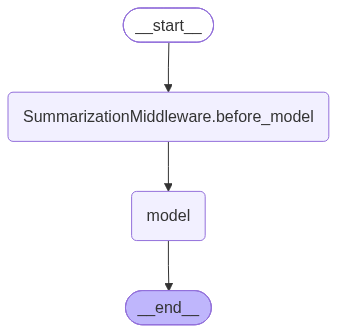

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# Agent with message based summarisation

agent = create_agent(
    model="gpt-5",
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-5",
            trigger=("messages",10),
            keep=("messages",4)
        )
    ]
)
agent

In [3]:
## thread id
config={"configurable":{"thread_id":"test1"}}

In [4]:
#Alternative test data
questions = [
    "What is 2+2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?",
]
for q in questions:
    response=agent.invoke({"messages":[HumanMessage(content=q)]}, config)
    print(f"Messages:{response}")
    print(f"Messages: {len(response['messages'])}")

Messages:{'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='3623bfa4-ead8-49ca-8c94-8dd86f0373f7'), AIMessage(content='4', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 13, 'total_tokens': 87, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EPOoq8HQELqAX5LkrOXcK5O3xP9pD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0b3c3-3547-70e2-8fc6-586f7bfeef48-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 74, 'total_tokens': 87, 'input_token_de

### Token size

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels - returns long response to use more tokens."""
    return f"""Hotels in {city}:
    1. Grand Hotel - 5 star, $350/night, spa, pool, gym
    2. City Inn - 4 star, $180/night, business center
    3. Budget Stay - 3 star, $75/night, free wifi"""

agent = create_agent(
    model = "gpt-5",
    tools = [search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model = "gpt-5",
            trigger =("tokens",500),
            keep = ("tokens",200),
        )
    ]
)

config = {"configurable": {"thread_id":"test-1"}}

# Token counter (approximate)
def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4  # 4 chars ≈ 1 token

In [6]:
# Run test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Find hotels in {city}")]},
        config=config
    )
    
    tokens = count_tokens(response["messages"])
    print(f"{city}: ~{tokens} tokens, {len(response['messages'])} messages")
    print(f"{(response['messages'])}")

Paris: ~150 tokens, 4 messages
[HumanMessage(content='Find hotels in Paris', additional_kwargs={}, response_metadata={}, id='d553f885-e2f3-4f64-b8e3-3ec2ff7237ac'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 152, 'prompt_tokens': 134, 'total_tokens': 286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 128, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-EPOw9my9DlohA9z3B6Y4PxKnsupo9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0b3ca-25fe-7122-9308-1265a5e01122-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_EoIsCt0HmTQjGTKEdS2Fe6bp', 

### Fraction

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

@tool
def search_hotels(city: str) -> str:
    """Search hotels."""
    return f"Hotels in {city}: Grand Hotel $350, City Inn $180, Budget Stay $75"

# LOW fraction for testing!
agent = create_agent(
    model="gpt-4o-mini",
    tools=[search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model="gpt-4o-mini",
            trigger=("fraction", 0.005),  # 0.5% = ~640 tokens
            keep=("fraction", 0.002),     # 0.2% = ~256 tokens
        ),
    ],
)

config = {"configurable": {"thread_id": "test-1"}}

# Token counter
def count_tokens(messages):
    return sum(len(str(m.content)) for m in messages) // 4

# Test
cities = ["Paris", "London", "Tokyo", "New York", "Dubai", "Singapore"]

for city in cities:
    response = agent.invoke(
        {"messages": [HumanMessage(content=f"Hotels in {city}")]},
        config=config
    )
    tokens = count_tokens(response["messages"])
    fraction = tokens / 128000  # gpt-4o-mini context
    print(f"{city}: ~{tokens} tokens ({fraction:.4%}), {len(response['messages'])} msgs")
    print(response['messages'])

Paris: ~68 tokens (0.0531%), 4 msgs
[HumanMessage(content='Hotels in Paris', additional_kwargs={}, response_metadata={}, id='5fbbbb97-10a8-4763-8967-9571a2a9c6e1'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 44, 'total_tokens': 59, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_c06c62446c', 'id': 'chatcmpl-EPP3fnfrIyJkoiZL7ueLF2ArdJi2g', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0b3d1-4187-7c20-8cc1-aae151ecfb81-0', tool_calls=[{'name': 'search_hotels', 'args': {'city': 'Paris'}, 'id': 'call_BnLTZn6eGpcpQxI

## Human In the Loop MiddleWare
Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:

High-stakes operations requiring human approval (e.g. database writes, financial transactions).
Compliance workflows where human oversight is mandatory.
Long-running conversations where human feedback guides the agent.

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

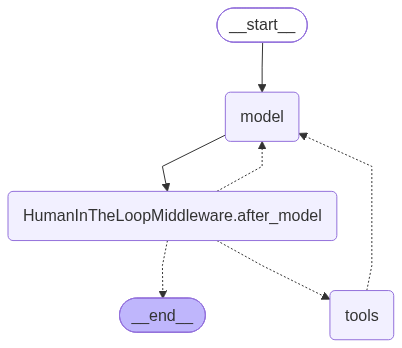

In [10]:
agent=create_agent(
    model="gpt-4o",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool":{
                    "allowed_decisions":["approve","edit","reject"]
                },
                "read_email_tool":False,

            }
        )
    ]
)
agent

In [11]:
config = {"configurable": {"thread_id": "test-approve"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config
)

In [12]:
result

{'messages': [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'", additional_kwargs={}, response_metadata={}, id='e52174d5-cc3a-4fef-94fd-2ec1180ccec2'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 97, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_5f6d02d065', 'id': 'chatcmpl-EPPABm9bNxJphz1OgWzuNevjcosLA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0b3d7-674d-7713-b574-8830d26847f5-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient'

In [13]:
from langgraph.types import Command
# Step 2: Approve
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "approve"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: The email has been sent to john@test.com with the subject "Hello."


In [14]:
config = {"configurable": {"thread_id": "test-reject"}}
# Step 1: Request
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to john@test.com with subject 'Hello' and body 'How are you?'")]},
    config=config)

In [15]:
# Step 2: Reject
if "__interrupt__" in result:
    print("⏸️ Paused! Approving...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {"type": "reject"}
                ]
            }
        ),
        config=config
    )
    
    print(f"✅ Result: {result['messages'][-1].content}")

⏸️ Paused! Approving...
✅ Result: It looks like there was an issue with sending the email. If you'd like to try again or make any changes, please let me know!


## Editing

In [16]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver


def read_email_tool(email_id: str) -> str:
    """Mock function to read an email by its ID."""
    return f"Email content for ID: {email_id}"

def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """Mock function to send an email."""
    return f"Email sent to {recipient} with subject '{subject}'"

agent = create_agent(
    model="gpt-4o",
    tools=[read_email_tool,send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email_tool": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "read_email_tool": False,
            }
        ),
    ],
)

In [17]:
config = {"configurable": {"thread_id": "test-edit"}}

# Step 1: Request (with wrong info)
result = agent.invoke(
    {"messages": [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'")]},
    config=config
)

In [18]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='419fe241-7660-4aef-b817-fe002d53c11a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 95, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_5f6d02d065', 'id': 'chatcmpl-EPPHiqAn7XzlzxZsGZziEA2sFGphC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0b3de-871d-7743-af81-1a73767fb897-0', tool_calls=[{'name': 'send_email_tool', 'args': {'recipient': 'wro

In [19]:
# Step 2: Edit and approve
if "__interrupt__" in result:
    print("⏸️ Paused! Editing...")
    
    result = agent.invoke(
        Command(
            resume={
                "decisions": [
                    {
                        "type": "edit",
                        "edited_action": {
                            "name": "send_email_tool",      # Tool name
                            "args": {                   # New arguments
                                "recipient": "correct@email.com",
                                "subject": "Corrected Subject",
                                "body": "This was edited by human before sending"
                            }
                        }
                    }
                ]
            }
        ),
        config=config
    )
    
    print(f"✏️ Result: {result['messages'][-1].content}")

⏸️ Paused! Editing...
✏️ Result: The email has been sent to correct@email.com with the subject 'Corrected Subject.'


In [20]:
result

{'messages': [HumanMessage(content="Send email to wrong@email.com with subject 'Test' and body 'Hello'", additional_kwargs={}, response_metadata={}, id='419fe241-7660-4aef-b817-fe002d53c11a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 95, 'total_tokens': 120, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_5f6d02d065', 'id': 'chatcmpl-EPPHiqAn7XzlzxZsGZziEA2sFGphC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0b3de-871d-7743-af81-1a73767fb897-0', tool_calls=[{'type': 'tool_call', 'name': 'send_email_tool', 'args